## Importação de bibliotecas

In [1]:
# configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

## Carga do Dataset

In [2]:
# Set the path to the file you'd like to load
file_path = "Titanic-Dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/titanic-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head(5)

100%|██████████| 59.8k/59.8k [00:00<00:00, 3.51MB/s]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Limpeza e Tratamento do Dataset

In [3]:


# Remove colunas de Nome, Ticket e Cabin
# Nome acaba sendo irrelevante e atrapalharia o modelo, Ticket e Cabin contém muitos NaN.
df_clean = df.drop(columns=['Name', 'Ticket', 'Cabin'], axis=1)
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_clean = pd.get_dummies(df_clean, columns=['Sex', 'Embarked'], drop_first=True)
cols = [col for col in df_clean.columns if col != 'Survived']
df_clean['Survived'] = df_clean['Survived'].astype(int)

cols.append('Survived')
df_clean = df_clean[cols]

# Validação
df_clean.head(15)

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Survived
0,1,3,22.0,1,0,7.2500,True,False,True,0
1,2,1,38.0,1,0,71.2833,False,False,False,1
2,3,3,26.0,0,0,7.9250,False,False,True,1
3,4,1,35.0,1,0,53.1000,False,False,True,1
4,5,3,35.0,0,0,8.0500,True,False,True,0
5,6,3,28.0,0,0,8.4583,True,True,False,0
6,7,1,54.0,0,0,51.8625,True,False,True,0
7,8,3,2.0,3,1,21.0750,True,False,True,0
8,9,3,27.0,0,2,11.1333,False,False,True,1
9,10,2,14.0,1,0,30.0708,False,False,False,1


## Separação em conjunto de treino

In [4]:
test_size = 0.20
seed = 7

array = df_clean.values
X = array[:, 0:-1] # Todas as colunas exceto a target
y = array[:, -1]   # Apenas a última target (Survived)

# Holdout com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, shuffle=True, random_state=seed, stratify=y
)

# 4. Parâmetros de Validação Cruzada
scoring = 'accuracy'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed)

print(f"X_train shape: {X_train.shape}")
print(f"y_train (Survived) labels: {set(y_train)}")

X_train shape: (712, 9)
y_train (Survived) labels: {0, 1}


## Modelagem e Inferência

### Criação e avaliação de modelos: linha base

--- Avaliação dos Modelos (Acurácia Média) ---
LR: 0.7991 (0.0349)
KNN: 0.6151 (0.0308)
CART: 0.7584 (0.0591)
NB: 0.7836 (0.0376)
SVM: 0.6460 (0.0241)
Bagging: 0.8175 (0.0284)
RF: 0.8272 (0.0399)
ET: 0.8034 (0.0349)
Ada: 0.8076 (0.0352)
GB: 0.8146 (0.0269)
Voting: 0.7992 (0.0327)


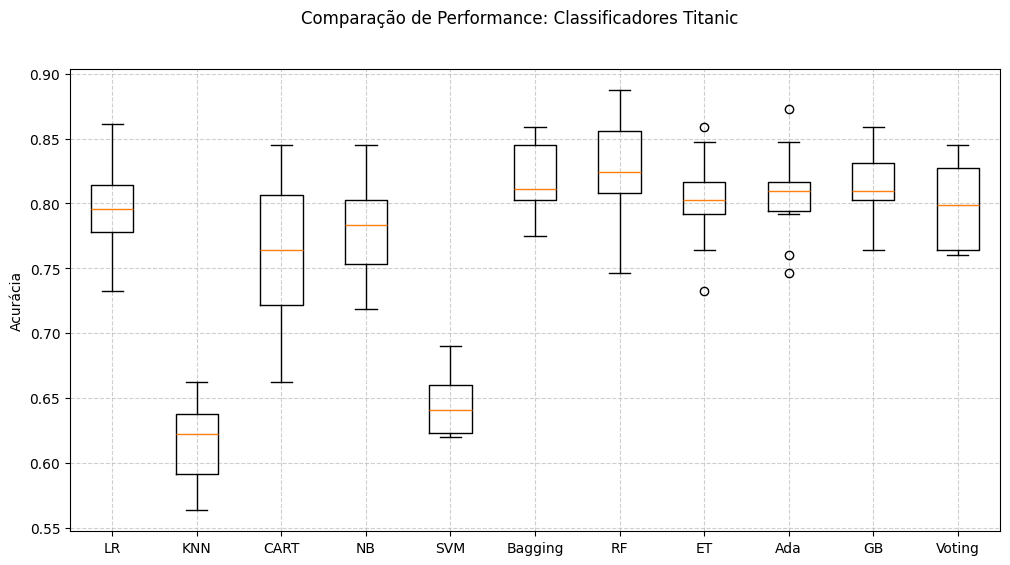

In [5]:
# Definindo a semente global para garantir reprodutibilidade
np.random.seed(seed)

# Lista que armazenará os modelos
models = []

# Modelos Base
models.append(('LR', LogisticRegression(max_iter=1000))) # Aumentei max_iter para evitar aviso de convergência
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Ensembles
num_trees = 100
max_features = 3

# Configuração do Voting
bases = [
    ('logistic', LogisticRegression(max_iter=1000)),
    ('cart', DecisionTreeClassifier()),
    ('svm', SVC(probability=True)) # probability=True se quiser usar soft voting depois
]

models.append(('Bagging', BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=num_trees)))
models.append(('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('Ada', AdaBoostClassifier(n_estimators=num_trees, algorithm='SAMME'))) # SAMME para evitar avisos em versões novas
models.append(('GB', GradientBoostingClassifier(n_estimators=num_trees)))
models.append(('Voting', VotingClassifier(bases)))

# Listas para armazenar os resultados
results = []
names = []


# Força a tipagem estrita para evitar matrizes do tipo 'object'
X_train = np.asarray(X_train, dtype='float')
y_train = np.asarray(y_train, dtype='int')

# ---------------------------------------
# Avaliação dos modelos (Loop principal)
print("--- Avaliação dos Modelos (Acurácia Média) ---")
for name, model in models:
    # O kfold e o scoring foram definidos na célula anterior
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    # Exibe Nome: Média (Desvio Padrão)
    msg = "%s: %.4f (%.4f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Boxplot de comparação (Visualização técnica)
fig = plt.figure(figsize=(12,6))
fig.suptitle('Comparação de Performance: Classificadores Titanic')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.ylabel('Acurácia')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Criação e avaliação de modelos: dados padronizados e normalizados

LR-orig: 0.796 (0.035)
KNN-orig: 0.615 (0.031)
CART-orig: 0.758 (0.059)
NB-orig: 0.784 (0.038)
SVM-orig: 0.646 (0.024)
Bag-orig: 0.817 (0.028)
RF-orig: 0.827 (0.040)
ET-orig: 0.803 (0.035)
Ada-orig: 0.808 (0.035)
GB-orig: 0.815 (0.027)
Vot-orig: 0.799 (0.033)
LR-padr: 0.793 (0.036)
KNN-padr: 0.795 (0.037)
CART-padr: 0.779 (0.059)
NB-padr: 0.784 (0.038)
SVM-padr: 0.806 (0.027)
Bag-padr: 0.825 (0.039)
RF-padr: 0.829 (0.035)
ET-padr: 0.805 (0.041)
Ada-padr: 0.808 (0.035)
GB-padr: 0.813 (0.028)
Vot-padr: 0.817 (0.033)
LR-norm: 0.796 (0.028)
KNN-norm: 0.779 (0.040)
CART-norm: 0.774 (0.062)
NB-norm: 0.784 (0.038)
SVM-norm: 0.820 (0.039)
Bag-norm: 0.820 (0.035)
RF-norm: 0.829 (0.030)
ET-norm: 0.808 (0.038)
Ada-norm: 0.808 (0.035)
GB-norm: 0.820 (0.037)
Vot-norm: 0.823 (0.037)


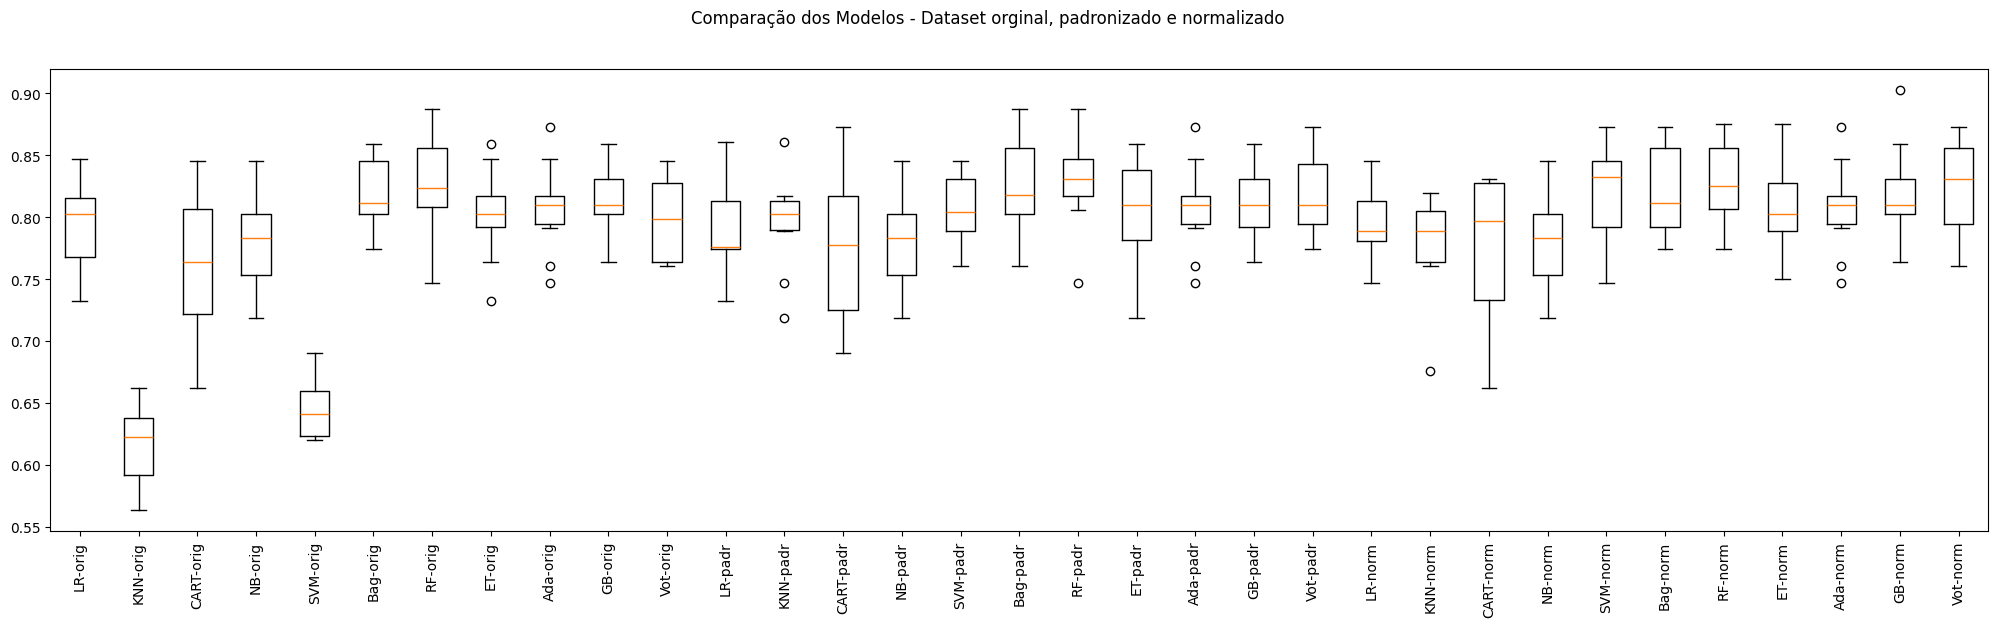

In [6]:
np.random.seed(7) # definindo uma semente global para este bloco

# Listas para armazenar os armazenar os pipelines e os resultados para todas as visões do dataset
pipelines = []
results = []
names = []


# Criando os elementos do pipeline

# Algoritmos que serão utilizados
reg_log = ('LR', LogisticRegression(max_iter=200))
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())
bagging = ('Bag', BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=num_trees))
random_forest = ('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features))
extra_trees = ('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features))
adaboost = ('Ada', AdaBoostClassifier(n_estimators=num_trees))
gradient_boosting = ('GB', GradientBoostingClassifier(n_estimators=num_trees))
voting = ('Voting', VotingClassifier(bases))

# Transformações que serão utilizadas
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())


# Montando os pipelines

# Dataset original
pipelines.append(('LR-orig', Pipeline([reg_log])))
pipelines.append(('KNN-orig', Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig', Pipeline([naive_bayes])))
pipelines.append(('SVM-orig', Pipeline([svm])))
pipelines.append(('Bag-orig', Pipeline([bagging])))
pipelines.append(('RF-orig', Pipeline([random_forest])))
pipelines.append(('ET-orig', Pipeline([extra_trees])))
pipelines.append(('Ada-orig', Pipeline([adaboost])))
pipelines.append(('GB-orig', Pipeline([gradient_boosting])))
pipelines.append(('Vot-orig', Pipeline([voting])))

# Dataset Padronizado
pipelines.append(('LR-padr', Pipeline([standard_scaler, reg_log])))
pipelines.append(('KNN-padr', Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
pipelines.append(('SVM-padr', Pipeline([standard_scaler, svm])))
pipelines.append(('Bag-padr', Pipeline([standard_scaler, bagging])))
pipelines.append(('RF-padr', Pipeline([standard_scaler, random_forest])))
pipelines.append(('ET-padr', Pipeline([standard_scaler, extra_trees])))
pipelines.append(('Ada-padr', Pipeline([standard_scaler, adaboost])))
pipelines.append(('GB-padr', Pipeline([standard_scaler, gradient_boosting])))
pipelines.append(('Vot-padr', Pipeline([standard_scaler, voting])))

# Dataset Normalizado
pipelines.append(('LR-norm', Pipeline([min_max_scaler, reg_log])))
pipelines.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
pipelines.append(('SVM-norm', Pipeline([min_max_scaler, svm])))
pipelines.append(('Bag-norm', Pipeline([min_max_scaler, bagging])))
pipelines.append(('RF-norm', Pipeline([min_max_scaler, random_forest])))
pipelines.append(('ET-norm', Pipeline([min_max_scaler, extra_trees])))
pipelines.append(('Ada-norm', Pipeline([min_max_scaler, adaboost])))
pipelines.append(('GB-norm', Pipeline([min_max_scaler, gradient_boosting])))
pipelines.append(('Vot-norm', Pipeline([min_max_scaler, voting])))

# Executando os pipelines
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

### Otimização dos hiperparâmetros

In [7]:
# 1. Definição do espaço de busca de hiperparâmetros para o Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],          # Número de árvores
    'max_depth': [None, 5, 10, 15],          # Profundidade máxima das árvores (evita overfitting)
    'min_samples_split': [2, 5, 10],         # Mínimo de amostras para dividir um nó
    'criterion': ['gini', 'entropy']         # Critério de pureza
}

print("Iniciando Grid Search para Random Forest...")

# 2. Configuração do modelo e do Grid Search
# Vamos usar os dados originais X_train, já que normalização não afeta árvores
rf_model = RandomForestClassifier(random_state=seed)
grid = GridSearchCV(estimator=rf_model, param_grid=param_grid, scoring=scoring, cv=kfold, n_jobs=-1)

# 3. Treinamento (A busca da melhor combinação)
grid_result = grid.fit(X_train, y_train)

# 4. Resultados da Otimização
print("--- Resultados da Otimização ---")
print("Melhor Acurácia: %.4f" % (grid_result.best_score_))
print("Melhores Parâmetros: %s" % (grid_result.best_params_))

Iniciando Grid Search para Random Forest...
--- Resultados da Otimização ---
Melhor Acurácia: 0.8343
Melhores Parâmetros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


## Finalização do Modelo

In [9]:


# 1. Correção de Tipagem (Type Casting)
# Garante que os arrays de treino e teste sejam matematicamente tratáveis
X_train = np.asarray(X_train, dtype='float')
y_train = np.asarray(y_train, dtype='int')
X_test = np.asarray(X_test, dtype='float')
y_test = np.asarray(y_test, dtype='int')

# 2. Preparação do modelo com os hiperparâmetros otimizados
model = RandomForestClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=2,
    n_estimators=100,
    random_state=seed # Se 'seed' der NameError, mude para 7
)

# 3. Treinamento final utilizando todo o conjunto de treino disponível
model.fit(X_train, y_train)

# 4. Inferência (Previsão) no conjunto de teste isolado
predictions = model.predict(X_test)

# 5. Avaliação de Performance
print("--- Avaliação no Conjunto de Teste ---")
print("Acurácia: %.4f" % accuracy_score(y_test, predictions))


--- Avaliação no Conjunto de Teste ---
Acurácia: 0.8268


In [10]:

# 1. Tipagem Estrita do Dataset Completo
# Aplicamos a correção de tipo aos vetores originais X e y (que contêm 100% dos dados)
# para evitar o erro de 'unknown target type' no Scikit-Learn.
X_full = np.asarray(X, dtype='float')
y_full = np.asarray(y, dtype='int')

# 2. Instanciação do Modelo Definitivo
# Utilizamos os hiperparâmetros descobertos no Grid Search.
# Omitimos o StandardScaler pois não afeta o ganho de informação (Gini/Entropy) das árvores.
modelo_final = RandomForestClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=2,
    n_estimators=100,
    random_state=seed # Utilizando a mesma seed global (7)
)

# 3. Treinamento (Fit) com todo o dataset
print("Iniciando treinamento do modelo final com 100% dos dados...")
modelo_final.fit(X_full, y_full)
print("Modelo final treinado e pronto para produção/inferência em dados não vistos.")

Iniciando treinamento do modelo final com 100% dos dados...
Modelo final treinado e pronto para produção/inferência em dados não vistos.


## Simulando a aplicação do modelo em dados não vistos

In [11]:
# 1. Novos dados fictícios (3 passageiros)
data = {
    'PassengerId': [1000, 1001, 1002],
    'Pclass': [1, 3, 2],            # Classe (1ª, 3ª, 2ª)
    'Age': [22.0, 20.0, 4.0],       # Idades
    'SibSp': [0, 0, 1],             # Irmãos/Cônjuges a bordo
    'Parch': [0, 0, 1],             # Pais/Filhos a bordo
    'Fare': [150.0, 7.5, 25.0],     # Tarifa paga
    'Sex_male': [0, 1, 1],          # 0 = Mulher, 1 = Homem
    'Embarked_Q': [0, 0, 0],        # Queenstown
    'Embarked_S': [0, 1, 1]         # Southampton (Se Q=0 e S=0, o embarque foi C)
}

# 2. Criação do DataFrame garantindo a ordem exata das colunas
atributos = ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
entrada = pd.DataFrame(data, columns=atributos)

# 3. Tratamento de Tipagem (Type Casting) para o modelo
# Extraímos os valores e forçamos para float, exatamente como feito no treino
array_entrada = entrada.values
X_entrada = np.asarray(array_entrada, dtype='float')

# 4. Inferência (Sem uso de StandardScaler para Random Forest)
print("--- Realizando Previsões em Dados Não Vistos ---")
previsoes = modelo_final.predict(X_entrada)

# 5. Exibição amigável dos resultados
for i in range(len(previsoes)):
    classe = "Sobreviveu" if previsoes[i] == 1 else "Não Sobreviveu"
    print(f"Passageiro {data['PassengerId'][i]} (Perfil {i+1}): {classe}")

--- Realizando Previsões em Dados Não Vistos ---
Passageiro 1000 (Perfil 1): Sobreviveu
Passageiro 1001 (Perfil 2): Não Sobreviveu
Passageiro 1002 (Perfil 3): Sobreviveu


In [12]:
# Predição de classes dos dados de entrada (sem padronização)
saidas = modelo_final.predict(X_entrada)

# Exibição do array bruto de resultados
# Esperado: Array contendo 0 (Não Sobreviveu) e 1 (Sobreviveu)
print(saidas)

[1 0 1]


## Exportar Modelo

In [ ]:
import joblib

# 1. Definição do nome/caminho do arquivo de saída
# A extensão .joblib ou .pkl é o padrão para modelos serializados
caminho_arquivo = 'modelo_titanic_rf.joblib'

# 2. Exportação (Serialização) do modelo
# O comando dump salva o estado exato do modelo treinado, incluindo os hiperparâmetros
joblib.dump(modelo_final, caminho_arquivo)

print(f"Modelo exportado com sucesso: {caminho_arquivo}")

Modelo exportado com sucesso: modelo_titanic_rf.joblib
